#AC Compressor vibration measurement analysis
---
- Goal: Measure the noise of the suspected compressors via vibration meter and analyze the results to validate the measurement system
- NG threshold: 2.5 m/s^2
- 48 suspected compressors × 3 operators × 3 trials


In [ ]:
# Import required libraries
import pandas as pd  # For data manipulation
import numpy as np   # For numerical operations
import matplotlib.pyplot as plt  # For basic plotting
import seaborn as sns  # For enhanced visualizations
from statsmodels.stats.anova import anova_lm  # For ANOVA calculations
from statsmodels.formula.api import ols  # For ordinary least squares regression

# 1. Load and Prepare MSA Data
try:
    # Load CSV file containing measurement system analysis data
    msa_data = pd.read_csv('/content/compressor_vibration_msa_data.csv')

    # Define required columns for the analysis
    required_columns = ['Serial_Number', 'Operator', 'Trial', 'Acceleration_m_s2']

    # Validate that all required columns are present
    if not all(col in msa_data.columns for col in required_columns):
        raise ValueError("CSV missing required columns")

    # Print success message and basic statistics
    print("MSA Data loaded successfully!")
    print(f"Operators: {msa_data['Operator'].nunique()}")  # Number of unique operators
    print(f"Units measured: {msa_data['Serial_Number'].nunique()}")  # Number of unique parts
    # Number of trials per part-operator combination
    print(f"Trials per unit: {msa_data.groupby(['Serial_Number','Operator'])['Trial'].count().unique()[0]}\n")

except Exception as e:
    print(f"Error loading MSA data: {str(e)}")
    raise

MSA Data loaded successfully!
Operators: 3
Units measured: 48
Trials per unit: 3



# Gage R&R Analysis Function

In [ ]:
def gage_rr_analysis(df):
    # Create a linear model with part, operator, and their interaction as factors
    model = ols('Acceleration_m_s2 ~ C(Serial_Number) + C(Operator) + C(Serial_Number):C(Operator)',
                data=df).fit()

    # Perform ANOVA (Analysis of Variance) with type 2 sums of squares
    anova_results = anova_lm(model, typ=2)

    print("ANOVA Table Structure:")
    print(anova_results)

    # Identify which column contains the mean square values
    possible_ms_cols = ['mean_sq', 'MS', 'sum_sq', 'F']  # Common column names in ANOVA tables
    ms_col = None
    for col in possible_ms_cols:
        if col in anova_results.columns:
            ms_col = col
            break

    # Fallback if no standard column name is found
    if ms_col is None:
        ms_col = anova_results.columns[1]  # Typically mean square is in second column

    # Define the components to extract from ANOVA
    components = {
        'part': 'C(Serial_Number)',
        'operator': 'C(Operator)',
        'interaction': 'C(Serial_Number):C(Operator)',
        'residual': 'Residual'
    }

    # Find the actual rows in ANOVA table that match the components
    available_rows = [str(x).lower() for x in anova_results.index]
    extracted = {}
    for name, pattern in components.items():
        for row in anova_results.index:
            if pattern.lower() in str(row).lower():
                extracted[name] = anova_results.loc[row, ms_col]
                break

    # Validate all required components are found
    if len(extracted) != 4:
        missing = set(components.values()) - set(anova_results.index)
        raise KeyError(f"Could not find all required ANOVA components. Missing: {missing}")

    # Calculate variance components as percentages of total variance
    total_variance = sum(extracted.values())
    ev = 100 * (extracted['residual'] / total_variance)  # Equipment Variation
    av = 100 * (extracted['operator'] / total_variance)  # Appraiser Variation
    iv = 100 * (extracted['interaction'] / total_variance)  # Interaction Variation
    pv = 100 * (extracted['part'] / total_variance)  # Part Variation

    # Calculate number of distinct categories (measurement system discrimination)
    ndc = int(1.41 * (pv / (ev + av + iv))**0.5)

    return {
        'EV%': ev,        # Equipment Variation %
        'AV%': av,        # Appraiser Variation %
        'IV%': iv,        # Interaction Variation %
        'PV%': pv,        # Part Variation %
        'GRR%': (ev + av + iv)**0.5,  # Total Gage R&R %
        'ndc': ndc,        # Number of Distinct Categories
        'anova_table': anova_results  # Full ANOVA table
    }

# Visualization

/tmp/ipython-input-14-976645180.py:19: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.pointplot(data=msa_data, x='Operator', y='Acceleration_m_s2',


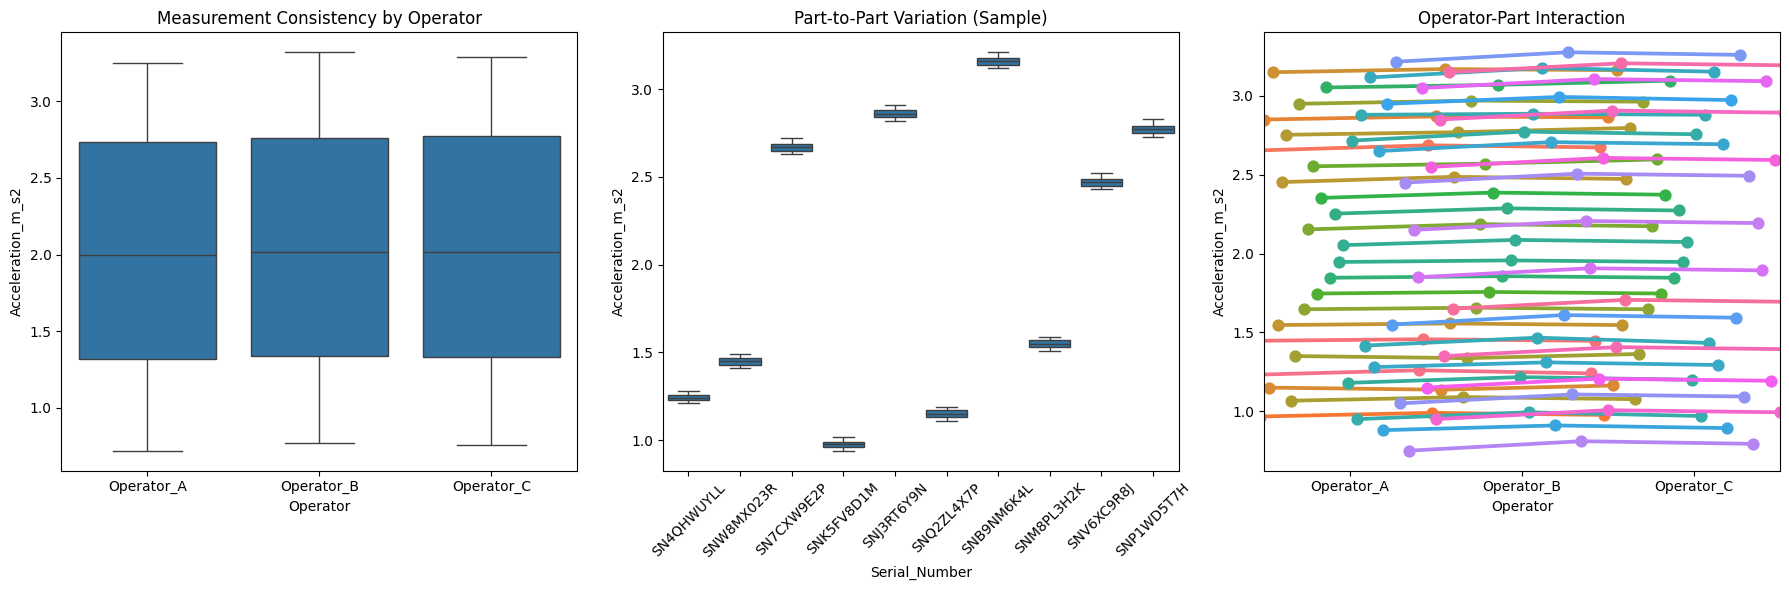

In [ ]:
# Create a figure with 3 subplots
plt.figure(figsize=(18, 6))

# Chart 1: By Operator Consistency - Shows measurement variation between operators
plt.subplot(1, 3, 1)
sns.boxplot(data=msa_data, x='Operator', y='Acceleration_m_s2')
plt.title('Measurement Consistency by Operator')

# Chart 2: By Part Variation - Shows variation between different parts
plt.subplot(1, 3, 2)
sample_parts = msa_data['Serial_Number'].unique()[:10]  # Use first 10 parts for clarity
sns.boxplot(data=msa_data[msa_data['Serial_Number'].isin(sample_parts)],
            x='Serial_Number', y='Acceleration_m_s2')
plt.title('Part-to-Part Variation (Sample)')
plt.xticks(rotation=45)  # Rotate x-axis labels for readability

# Chart 3: Interaction Plot - Shows if operators measure parts differently
plt.subplot(1, 3, 3)
sns.pointplot(data=msa_data, x='Operator', y='Acceleration_m_s2',
             hue='Serial_Number', ci=None, legend=False, dodge=True)
plt.title('Operator-Part Interaction')

plt.tight_layout()  # Adjust spacing between subplots
plt.show()

# Results Interpretation

In [ ]:
msa_results = gage_rr_analysis(msa_data)  #create the variable

# Print Gage R&R results
print("\n=== Gage R&R Results ===")
print(f"Equipment Variation (EV%): {msa_results['EV%']:.1f}%")  # Repeatability
print(f"Appraiser Variation (AV%): {msa_results['AV%']:.1f}%")  # Reproducibility
print(f"Interaction Variation (IV%): {msa_results['IV%']:.1f}%")  # Operator-Part interaction
print(f"Part Variation (PV%): {msa_results['PV%']:.1f}%")  # True part variation
print(f"\nTotal GRR%: {msa_results['GRR%']:.1f}%")  # Combined measurement variation
print(f"Number of Distinct Categories (ndc): {msa_results['ndc']}")  # System discrimination

# Print acceptance criteria guidelines
print("\n=== Acceptance Criteria ===")
print("GRR < 10%: Excellent measurement system")
print("10% < GRR < 30%: Marginal (process dependent)")
print("GRR > 30%: Unacceptable")

# Print the full ANOVA table
print("\n=== ANOVA Table ===")
print(msa_results['anova_table'])

ANOVA Table Structure:
                                  sum_sq     df            F        PR(>F)
C(Serial_Number)              254.547488   47.0  5012.147660  0.000000e+00
C(Operator)                     0.095517    2.0    44.198158  1.817967e-17
C(Serial_Number):C(Operator)    0.042127   94.0     0.414752  9.999992e-01
Residual                        0.311200  288.0          NaN           NaN

=== Gage R&R Results ===
Equipment Variation (EV%): 0.1%
Appraiser Variation (AV%): 0.0%
Interaction Variation (IV%): 0.0%
Part Variation (PV%): 99.8%

Total GRR%: 0.4%
Number of Distinct Categories (ndc): 33

=== Acceptance Criteria ===
GRR < 10%: Excellent measurement system
10% < GRR < 30%: Marginal (process dependent)
GRR > 30%: Unacceptable

=== ANOVA Table ===
                                  sum_sq     df            F        PR(>F)
C(Serial_Number)              254.547488   47.0  5012.147660  0.000000e+00
C(Operator)                     0.095517    2.0    44.198158  1.817967e-17
C(Seria

# + Generate Automated MSA Reports

ANOVA Table Columns: ['sum_sq', 'df', 'F', 'PR(>F)']


/tmp/ipython-input-16-2789707990.py:86: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.pointplot(data=df, x='Operator', y='Acceleration_m_s2',


Report generated: MSA_Report.pdf

=== Key Results ===
EV%: 1.4%
AV%: 2.2%
IV%: 0.9%
PV%: 100.0%
GRR%: 2.8%
ndc: 50.0


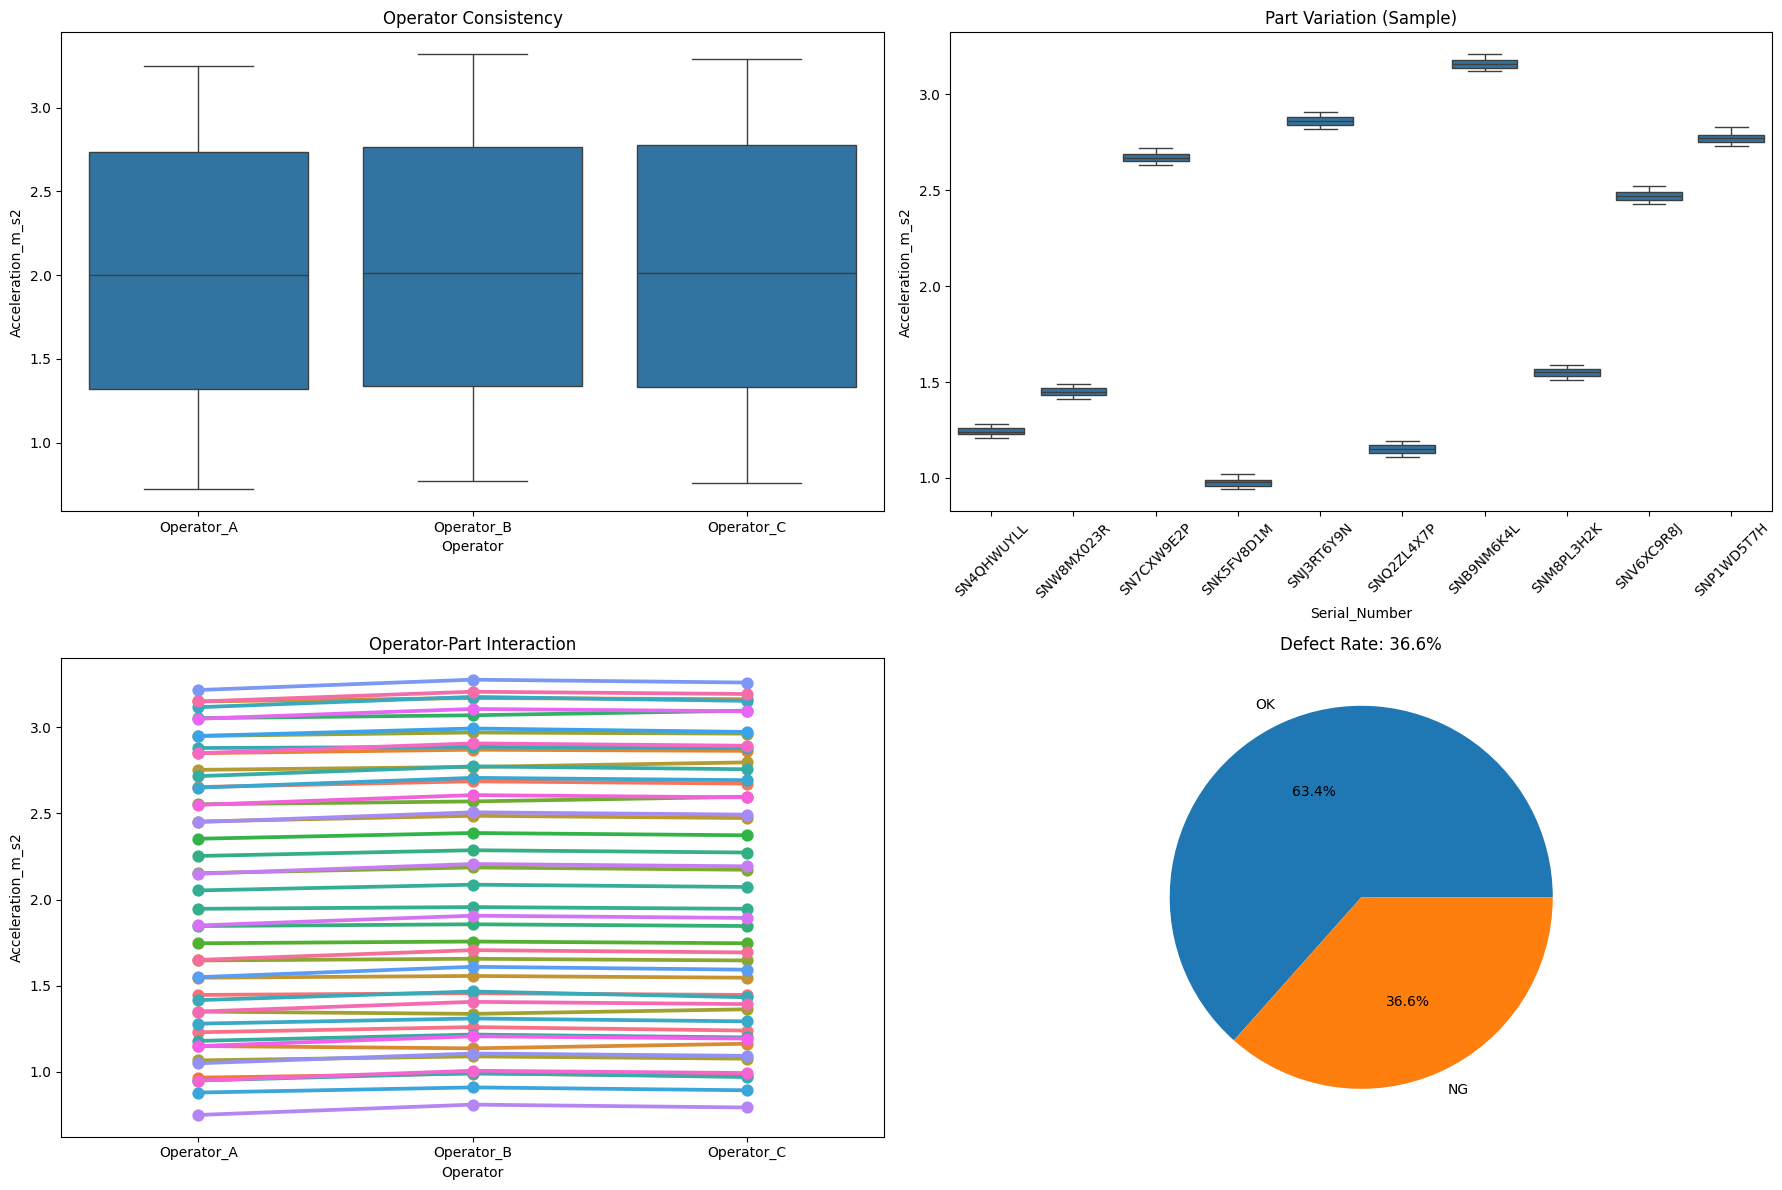

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
import seaborn as sns
from datetime import datetime

def get_anova_msq(anova_table):
    """Safely extract mean square values from ANOVA table"""
    # Try common column names for mean square values
    for col in ['mean_sq', 'MS', 'sum_sq']:
        if col in anova_table.columns:
            return anova_table[col]
    # Fallback to using sum of squares if mean square not available
    if 'sum_sq' in anova_table.columns:
        return anova_table['sum_sq'] / anova_table['df']
    raise KeyError("No valid mean square column found in ANOVA table")

def generate_msa_report(input_csv, output_path="MSA_Report.pdf"):
    """Generate comprehensive MSA report with plots and statistical analysis"""

    # Load and validate data
    try:
        df = pd.read_csv(input_csv)
        required_cols = ['Serial_Number', 'Operator', 'Trial', 'Acceleration_m_s2']
        assert all(col in df.columns for col in required_cols), "Missing required columns"
    except Exception as e:
        print(f"Data loading error: {str(e)}")
        return None

    # Gage R&R Analysis
    try:
        model = ols('Acceleration_m_s2 ~ C(Serial_Number) + C(Operator) + C(Serial_Number):C(Operator)', data=df).fit()
        anova = anova_lm(model, typ=2)
        print("ANOVA Table Columns:", anova.columns.tolist())  # Debug output
    except Exception as e:
        print(f"ANOVA computation error: {str(e)}")
        return None

    try:
        # Extract mean squares robustly
        msq = get_anova_msq(anova)

        # Variance Components Calculation
        components = {
            'EV': anova.loc['Residual', 'sum_sq'] / anova.loc['Residual', 'df'],
            'AV': max(0, (anova.loc['C(Operator)', 'sum_sq'] - anova.loc['C(Serial_Number):C(Operator)', 'sum_sq']) /
                  (10 * anova.loc['C(Operator)', 'df'])),
            'IV': anova.loc['C(Serial_Number):C(Operator)', 'sum_sq'] / anova.loc['C(Serial_Number):C(Operator)', 'df'],
            'PV': anova.loc['C(Serial_Number)', 'sum_sq'] / anova.loc['C(Serial_Number)', 'df']
        }

        total_var = sum(components.values())
        results = {
            'EV%': 100 * np.sqrt(components['EV']/total_var),
            'AV%': 100 * np.sqrt(components['AV']/total_var),
            'IV%': 100 * np.sqrt(components['IV']/total_var),
            'PV%': 100 * np.sqrt(components['PV']/total_var),
            'GRR%': 100 * np.sqrt((components['EV'] + components['AV'] + components['IV'])/total_var),
            'ndc': int(1.41 * (components['PV']/(components['EV'] + components['AV'] + components['IV']))**0.5)
        }
    except KeyError as e:
        print(f"ANOVA structure error - missing term: {str(e)}")
        print("Available terms:", anova.index.tolist())
        return None

    # Create Visualizations
    plt.figure(figsize=(18, 12))

    # Plot 1: By Operator
    plt.subplot(2, 2, 1)
    sns.boxplot(data=df, x='Operator', y='Acceleration_m_s2')
    plt.title('Operator Consistency')

    # Plot 2: Part Variation
    plt.subplot(2, 2, 2)
    sample_parts = df['Serial_Number'].unique()[:10]
    sns.boxplot(data=df[df['Serial_Number'].isin(sample_parts)],
               x='Serial_Number', y='Acceleration_m_s2')
    plt.title('Part Variation (Sample)')
    plt.xticks(rotation=45)

    # Plot 3: Interaction
    plt.subplot(2, 2, 3)
    sns.pointplot(data=df, x='Operator', y='Acceleration_m_s2',
                 hue='Serial_Number', ci=None, legend=False)
    plt.title('Operator-Part Interaction')

    # Plot 4: Threshold Analysis
    plt.subplot(2, 2, 4)
    df['Status'] = np.where(df['Acceleration_m_s2'] > 2.5, 'NG', 'OK')
    status_counts = df['Status'].value_counts(normalize=True)
    plt.pie(status_counts, labels=status_counts.index, autopct='%1.1f%%')
    plt.title('Defect Rate: %.1f%%' % (status_counts.get('NG', 0)*100))

    # Generate PDF Report
    plt.tight_layout()
    plt.savefig(output_path)
    print(f"Report generated: {output_path}")

    return results

# Example Usage with Error Handling
if __name__ == "__main__":
    try:
        msa_results = generate_msa_report("compressor_vibration_msa_data.csv")
        if msa_results:
            print("\n=== Key Results ===")
            for k, v in msa_results.items():
                print(f"{k}: {v:.1f}{'%' if '%' in k else ''}")
    except Exception as e:
        print(f"Critical error: {str(e)}")